In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
order_data = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")
order_items_data = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")


In [3]:
# Thông tin tổng quan về các cột
order_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [4]:
# Kiểm tra giá trị khuyết
missing = order_data.isnull().sum()
missing_pct = 100 * missing / len(order_data)
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ %': missing_pct})
missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)

,Số lượng thiếu,Tỷ lệ %
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


### **Nhận xét:**  
##### - Các cột `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` có giá trị khuyết, chủ yếu ở các đơn hàng chưa hoàn tất.
##### - Sẽ xử lý khi tính toán các chỉ số thời gian (chỉ lấy đơn đã giao).

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


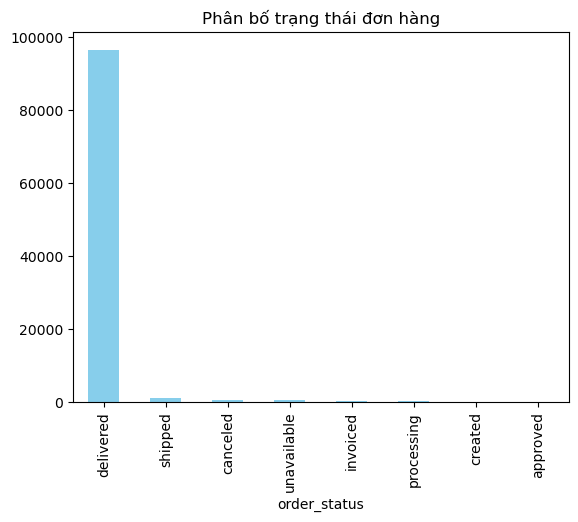

In [5]:
# Phân tích trạng thái đơn hàng
status_counts = order_data['order_status'].value_counts()
print(status_counts)
status_counts.plot(kind='bar', color='skyblue')
plt.title('Phân bố trạng thái đơn hàng')
plt.show()

2016-09-04 21:15:19 -> 2018-10-17 17:30:18


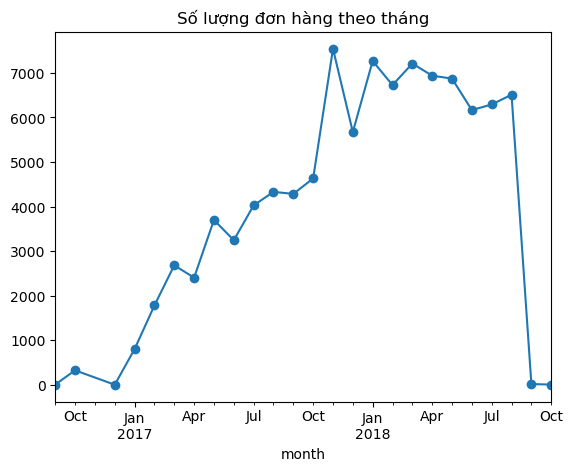

In [6]:
# Chuyển sang datetime
order_data['order_purchase_timestamp'] = pd.to_datetime(order_data['order_purchase_timestamp'])
# Phạm vi thời gian
print(order_data['order_purchase_timestamp'].min(), '->', order_data['order_purchase_timestamp'].max())
# Số đơn theo tháng
order_data['month'] = order_data['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = order_data.groupby('month').size()
monthly_orders.plot(kind='line', marker='o')
plt.title('Số lượng đơn hàng theo tháng')
plt.show()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


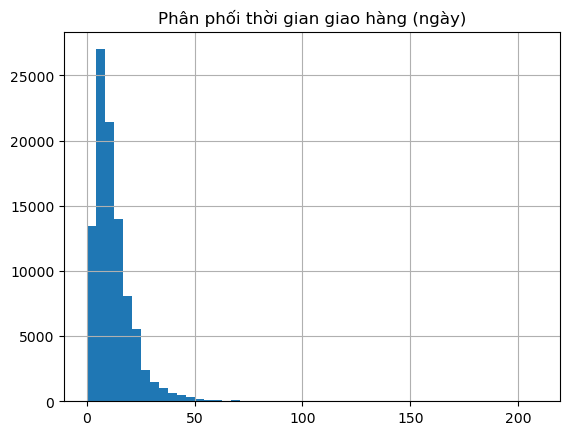

In [14]:
# Chuyển đổi kiểu dữ liệu cho toàn bộ bảng orders
order_data['order_purchase_timestamp'] = pd.to_datetime(order_data['order_purchase_timestamp'])
order_data['order_delivered_customer_date'] = pd.to_datetime(order_data['order_delivered_customer_date'])
#Phân tích thời gian giao hàng (chỉ với đơn delivered)
delivered = order_data[order_data['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
# Xem phân phối
print(delivered['delivery_days'].describe())
delivered['delivery_days'].hist(bins=50)
plt.title('Phân phối thời gian giao hàng (ngày)')
plt.show()

In [24]:
#tất cả cột ngày đều là datetime
order_data['order_estimated_delivery_date'] = pd.to_datetime(order_data['order_estimated_delivery_date'])

# Lọc đơn đã giao
delivered = order_data[order_data['order_status'] == 'delivered'].copy()

# Tính độ trễ (số ngày trễ hơn so với dự kiến, nếu dương là trễ)
delivered['delay'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
print(delivered['delay'].describe())
# Tỷ lệ giao trễ (delay > 0)
print(f"Tỷ lệ giao trễ: {(delivered['delay'] > 0).mean():.2%}")

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay, dtype: float64
Tỷ lệ giao trễ: 6.77%


Text(0.5, 1.0, 'Số đơn theo thứ (0=Monday)')

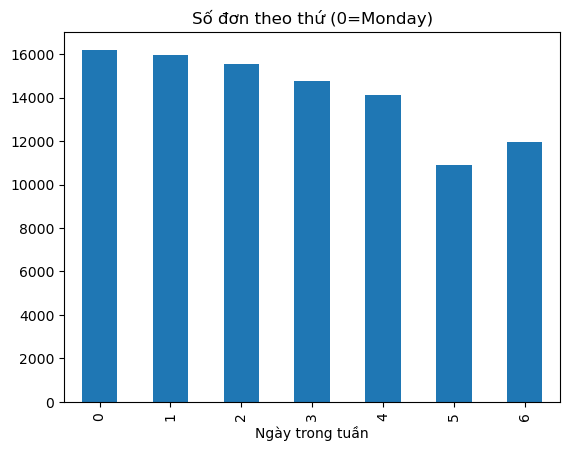

In [20]:
#Xu hướng đơn hàng theo giờ trong ngày, ngày trong tuần
order_data['hour'] = order_data['order_purchase_timestamp'].dt.hour
order_data['Ngày trong tuần'] = order_data['order_purchase_timestamp'].dt.dayofweek
order_data.groupby('hour').size().plot(kind='bar')
plt.title('Số đơn theo giờ')
order_data.groupby('Ngày trong tuần').size().plot(kind='bar')
plt.title('Số đơn theo thứ (0=Monday)')

In [28]:
# Tạo cột delivery_days
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days

# Kiểm tra kết quả
print(delivered[['order_id', 'delivery_days']].head())
#Phát hiện outlier (thời gian giao quá dài) Lọc delivery_days > 30 (bất thường)
outliers = delivered[delivered['delivery_days'] > 30]
print(f"Số đơn giao quá 30 ngày: {len(outliers)}")

                           order_id  delivery_days
0  e481f51cbdc54678b7cc49136f2d6af7            8.0
1  53cdb2fc8bc7dce0b6741e2150273451           13.0
2  47770eb9100c2d0c44946d9cf07ec65d            9.0
3  949d5b44dbf5de918fe9c16f97b45f8a           13.0
4  ad21c59c0840e6cb83a9ceb5573f8159            2.0
Số đơn giao quá 30 ngày: 4117


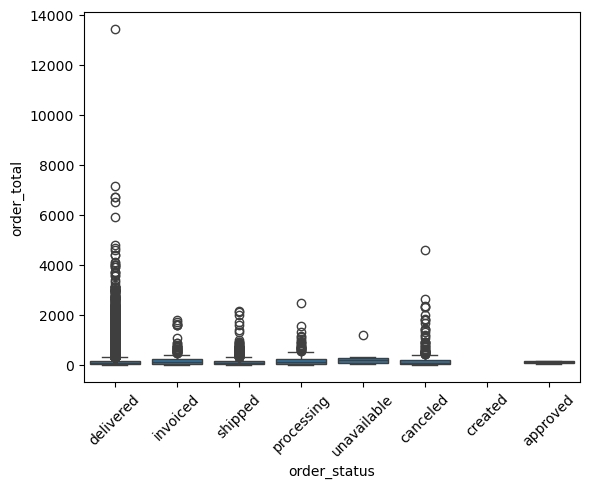

In [22]:
#Kết hợp thêm order_items để phân tích giá trị đơn hàng
order_total = order_items_data.groupby('order_id')['price'].sum().reset_index(name='order_total')
orders_with_total = order_data.merge(order_total, on='order_id', how='left')
# Thống kê giá trị đơn
orders_with_total['order_total'].describe()
# Boxplot theo trạng thái đơn
sns.boxplot(x='order_status', y='order_total', data=orders_with_total)
plt.xticks(rotation=45)
plt.show()